# NHS England A&E 4-Hour Performance Analysis (April 2022 – March 2026)
**Data:** NHS England "A&E Attendances and Emergency Admissions" monthly provider-level statistics — 48 monthly CSV files (Open Government Licence).

**Questions:** How has 4-hour performance changed against the 95% constitutional standard and the 78% interim target for March 2026? Which regions and trusts struggle most? How is University Hospitals of Leicester performing? Can we forecast attendance demand to support winter planning?

In [1]:
import pandas as pd, numpy as np, glob, re, sqlite3, matplotlib.pyplot as plt, seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
sns.set_theme(style="whitegrid"); pd.set_option("display.width",140)
files = sorted(glob.glob("data/*.csv")); print(len(files), "monthly files")

48 monthly files


## 1. Combine 48 files and run data quality checks

In [2]:
frames, issues = [], []
for f in files:
    x = pd.read_csv(f)
    extra = [c for c in x.columns if c.startswith("Unnamed") or c == "a"]
    if extra: issues.append((f.split("/")[-1], f"{len(extra)} empty/stray columns removed"))
    x = x.drop(columns=extra)
    frames.append(x)
raw = pd.concat(frames, ignore_index=True)
is_total = (~raw["Period"].astype(str).str.startswith("MSitAE")) | (raw["Org Code"].astype(str).str.strip().str.upper()=="TOTAL")
print("Summary 'TOTAL' rows found (5 different spellings, one hidden under a normal month label):", int(is_total.sum()), "rows removed to avoid double counting")
totals = raw[is_total].copy()
raw = raw[~is_total].copy()
# Reconciliation: provider rows must add up to each file's published TOTAL row (Type 1 attendances)
tot_t1 = totals["A&E attendances Type 1"].sum(); prov_t1 = raw["A&E attendances Type 1"].sum()
print(f"Reconciliation – Type 1 attendances: providers {prov_t1:,} vs published totals {tot_t1:,} -> difference {prov_t1-tot_t1:,}")
raw["month"] = pd.to_datetime(raw["Period"].str.replace("MSitAE-","").str.title(), format="%B-%Y")
print("region names with stray spaces:", int((raw["Parent Org"]!=raw["Parent Org"].str.strip()).sum()))
raw["Parent Org"] = raw["Parent Org"].str.strip()
cols = {"A&E attendances Type 1":"att_t1","A&E attendances Type 2":"att_t2","A&E attendances Other A&E Department":"att_oth",
 "A&E attendances Booked Appointments Type 1":"bk_t1","A&E attendances Booked Appointments Type 2":"bk_t2","A&E attendances Booked Appointments Other Department":"bk_oth",
 "Attendances over 4hrs Type 1":"o4_t1","Attendances over 4hrs Type 2":"o4_t2","Attendances over 4hrs Other Department":"o4_oth",
 "Attendances over 4hrs Booked Appointments Type 1":"o4bk_t1","Attendances over 4hrs Booked Appointments Type 2":"o4bk_t2","Attendances over 4hrs Booked Appointments Other Department":"o4bk_oth",
 "Patients who have waited 4-12 hs from DTA to admission":"dta_4_12","Patients who have waited 12+ hrs from DTA to admission":"dta_12",
 "Emergency admissions via A&E - Type 1":"adm_t1","Emergency admissions via A&E - Type 2":"adm_t2","Emergency admissions via A&E - Other A&E department":"adm_oth","Other emergency admissions":"adm_other"}
ae = raw.rename(columns=cols)[["month","Org Code","Parent Org","Org name"]+list(cols.values())]
num = list(cols.values())
checks = {
 "rows": len(ae), "months": ae.month.nunique(), "providers": ae["Org Code"].nunique(),
 "duplicate provider-month rows": int(ae.duplicated(["month","Org Code"]).sum()),
 "missing numeric values": int(ae[num].isna().sum().sum()),
 "negative values": int((ae[num]<0).sum().sum()),
 "rows where over-4hr > attendances (Type 1)": int((ae.o4_t1+ae.o4bk_t1 > ae.att_t1+ae.bk_t1).sum()),
}
print(checks); print(issues)
ae[num] = ae[num].fillna(0)

Summary 'TOTAL' rows found (5 different spellings, one hidden under a normal month label): 48 rows removed to avoid double counting
Reconciliation – Type 1 attendances: providers 65,181,714 vs published totals 65,181,714 -> difference 0
region names with stray spaces: 8363
{'rows': 9623, 'months': 48, 'providers': 221, 'duplicate provider-month rows': 0, 'missing numeric values': 0, 'negative values': 0, 'rows where over-4hr > attendances (Type 1)': 0}
[('Monthly-AE-September-2024.csv', '6 empty/stray columns removed')]


## 2. KPIs in SQL
4-hour performance = % of all A&E attendances (all types, incl. booked appointments) seen, admitted, transferred or discharged within 4 hours — the official NHS England definition.

In [3]:
con = sqlite3.connect(":memory:"); ae.assign(month=ae.month.dt.strftime("%Y-%m-%d")).to_sql("ae", con, index=False)
ATT = "(att_t1+att_t2+att_oth+bk_t1+bk_t2+bk_oth)"; O4 = "(o4_t1+o4_t2+o4_oth+o4bk_t1+o4bk_t2+o4bk_oth)"
q = {}
q["national_monthly"] = f"""
SELECT month, SUM({ATT}) AS attendances, SUM({O4}) AS over_4hrs,
       ROUND(100.0*(SUM({ATT})-SUM({O4}))/SUM({ATT}),1) AS pct_within_4hrs,
       ROUND(100.0*(SUM(att_t1+bk_t1)-SUM(o4_t1+o4bk_t1))/SUM(att_t1+bk_t1),1) AS type1_pct_within_4hrs,
       SUM(dta_12) AS waits_12hr_from_decision_to_admit,
       SUM(adm_t1+adm_t2+adm_oth+adm_other) AS emergency_admissions
FROM ae GROUP BY month ORDER BY month;"""
q["financial_year_summary"] = f"""
SELECT CASE WHEN CAST(strftime('%m',month) AS INT)>=4 THEN strftime('%Y',month) ELSE CAST(strftime('%Y',month)-1 AS TEXT) END AS fy_start,
       ROUND(SUM({ATT})/1e6,2) AS attendances_m,
       ROUND(100.0*(SUM({ATT})-SUM({O4}))/SUM({ATT}),1) AS pct_within_4hrs,
       SUM(dta_12) AS waits_12hr_dta
FROM ae GROUP BY fy_start ORDER BY fy_start;"""
q["region_latest_year"] = f"""
SELECT "Parent Org" AS region, ROUND(SUM({ATT})/1e6,2) AS attendances_m,
       ROUND(100.0*(SUM({ATT})-SUM({O4}))/SUM({ATT}),1) AS pct_within_4hrs,
       RANK() OVER (ORDER BY 1.0*SUM({O4})/SUM({ATT})) AS rank_best
FROM ae WHERE month >= '2025-04-01' GROUP BY region ORDER BY rank_best;"""
q["worst_type1_trusts_latest_year"] = f"""
WITH t AS (SELECT "Org name" AS trust, SUM(att_t1+bk_t1) AS t1_att, SUM(o4_t1+o4bk_t1) AS t1_o4
           FROM ae WHERE month >= '2025-04-01' GROUP BY trust HAVING SUM(att_t1+bk_t1) > 50000)
SELECT trust, t1_att AS type1_attendances, ROUND(100.0*(t1_att-t1_o4)/t1_att,1) AS type1_pct_within_4hrs
FROM t ORDER BY type1_pct_within_4hrs LIMIT 10;"""
q["leicester_vs_england"] = f"""
SELECT month,
  ROUND(100.0*(SUM(CASE WHEN "Org Code"='RWE' THEN {ATT} END)-SUM(CASE WHEN "Org Code"='RWE' THEN {O4} END))/SUM(CASE WHEN "Org Code"='RWE' THEN {ATT} END),1) AS leicester_pct,
  ROUND(100.0*(SUM({ATT})-SUM({O4}))/SUM({ATT}),1) AS england_pct
FROM ae GROUP BY month ORDER BY month;"""
res = {k: pd.read_sql(v, con) for k,v in q.items()}
open("sql/kpi_queries.sql","w").write("\n\n".join(f"-- {k}\n{v.strip()}" for k,v in q.items()))
print(ae.loc[ae["Org Code"]=="RWE","Org name"].unique())
for k in ["financial_year_summary","region_latest_year","worst_type1_trusts_latest_year"]: print(f"\n### {k}\n", res[k].to_string(index=False))

<StringArray>
['UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST']
Length: 1, dtype: str

### financial_year_summary
 fy_start  attendances_m  pct_within_4hrs  waits_12hr_dta
    2022          25.35             73.9          410092
    2023          26.32             72.6          439411
    2024          27.37             73.9          532451
    2025          27.97             74.9          570931

### region_latest_year
                               region  attendances_m  pct_within_4hrs  rank_best
                  NHS ENGLAND LONDON           4.90             77.2          1
              NHS ENGLAND SOUTH EAST           4.29             77.1          2
NHS ENGLAND NORTH EAST AND YORKSHIRE           4.40             76.0          3
         NHS ENGLAND EAST OF ENGLAND           2.81             74.9          4
                NHS ENGLAND MIDLANDS           5.17             73.0          5
              NHS ENGLAND SOUTH WEST           2.47             72.8          6
              NHS

In [4]:
nat = res["national_monthly"].assign(month=lambda x: pd.to_datetime(x.month))
print(nat[["month","attendances","pct_within_4hrs","type1_pct_within_4hrs","waits_12hr_from_decision_to_admit"]].iloc[[0,11,12,23,24,35,36,47]].to_string(index=False))

     month  attendances  pct_within_4hrs  type1_pct_within_4hrs  waits_12hr_from_decision_to_admit
2022-04-01      2028796             75.2                   64.0                              24179
2023-03-01      2165951             74.6                   62.3                              39687
2023-04-01      2034040             77.3                   65.8                              26492
2024-03-01      2370221             74.3                   60.9                              42972
2024-04-01      2240668             74.5                   60.4                              42078
2025-03-01      2389064             75.0                   60.9                              46766
2025-04-01      2297421             74.8                   60.2                              44648
2026-03-01      2432253             77.1                   64.1                              46665


## 3. Visual analysis

Average monthly 4-hour performance by financial year (start year):
       leicester_pct  england_pct
fy                              
2022           54.7         74.0
2023           57.2         72.6
2024           60.2         73.9
2025           62.8         74.9


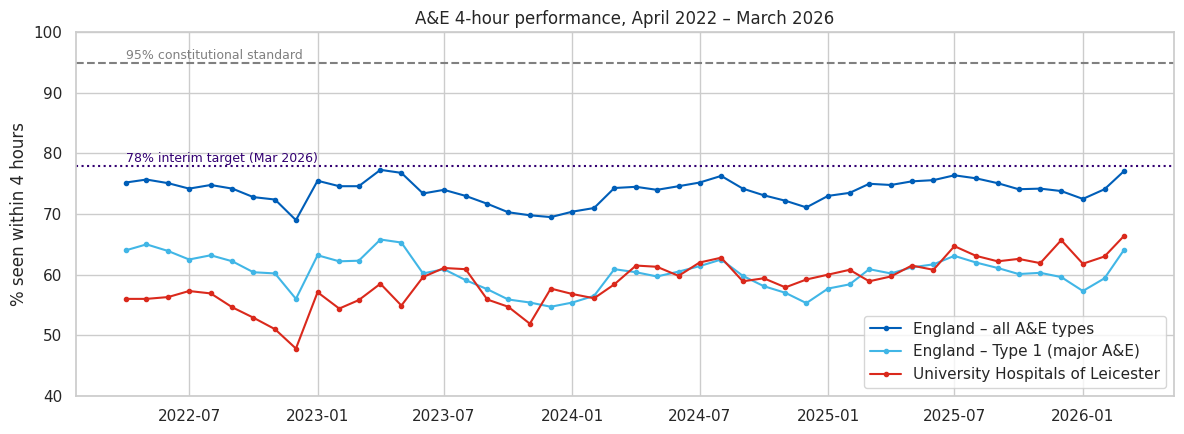

In [5]:
lei = res["leicester_vs_england"].assign(month=lambda x: pd.to_datetime(x.month))
lei["fy"] = np.where(lei.month.dt.month>=4, lei.month.dt.year, lei.month.dt.year-1)
print("Average monthly 4-hour performance by financial year (start year):\n", lei.groupby("fy")[["leicester_pct","england_pct"]].mean().round(1).to_string())
fig, ax = plt.subplots(figsize=(12,4.5))
ax.plot(nat.month, nat.pct_within_4hrs, marker="o", ms=3, label="England – all A&E types", color="#005EB8")
ax.plot(nat.month, nat.type1_pct_within_4hrs, marker="o", ms=3, label="England – Type 1 (major A&E)", color="#41B6E6")
ax.plot(lei.month, lei.leicester_pct, marker="o", ms=3, label="University Hospitals of Leicester", color="#DA291C")
ax.axhline(95, ls="--", color="grey"); ax.text(nat.month.iloc[0], 95.6, "95% constitutional standard", fontsize=9, color="grey")
ax.axhline(78, ls=":", color="#330072"); ax.text(nat.month.iloc[0], 78.6, "78% interim target (Mar 2026)", fontsize=9, color="#330072")
ax.set(title="A&E 4-hour performance, April 2022 – March 2026", ylabel="% seen within 4 hours", ylim=(40,100)); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig("charts/four_hour_performance.png", dpi=150); plt.show()

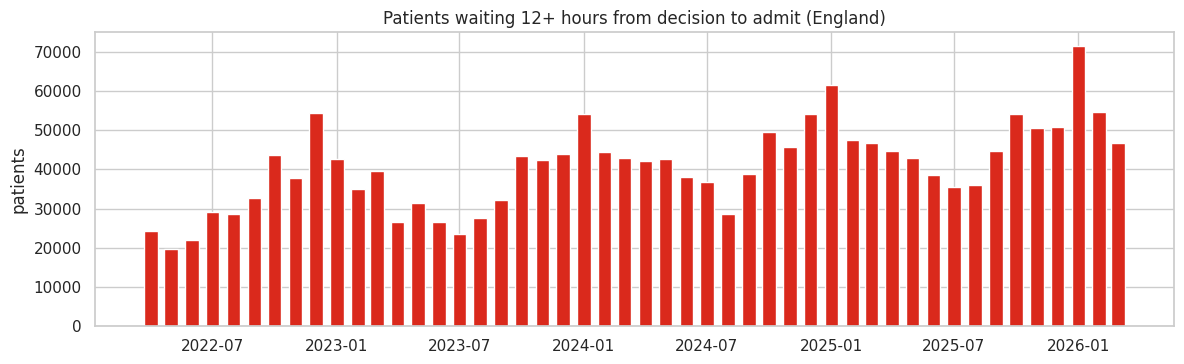

In [6]:
fig, ax = plt.subplots(figsize=(12,3.8))
ax.bar(nat.month, nat.waits_12hr_from_decision_to_admit, width=20, color="#DA291C")
ax.set(title="Patients waiting 12+ hours from decision to admit (England)", ylabel="patients")
plt.tight_layout(); plt.savefig("charts/twelve_hour_waits.png", dpi=150); plt.show()

## 4. Forecasting monthly A&E attendances (demand planning)
Holt-Winters exponential smoothing (additive trend, multiplicative yearly seasonality). Trained on Apr 2022 – Mar 2025, tested on the 12 unseen months Apr 2025 – Mar 2026, compared with a seasonal-naive baseline (same month last year).

                     model  MAPE %
              Holt-Winters    1.72
Seasonal naive (last year)    2.44


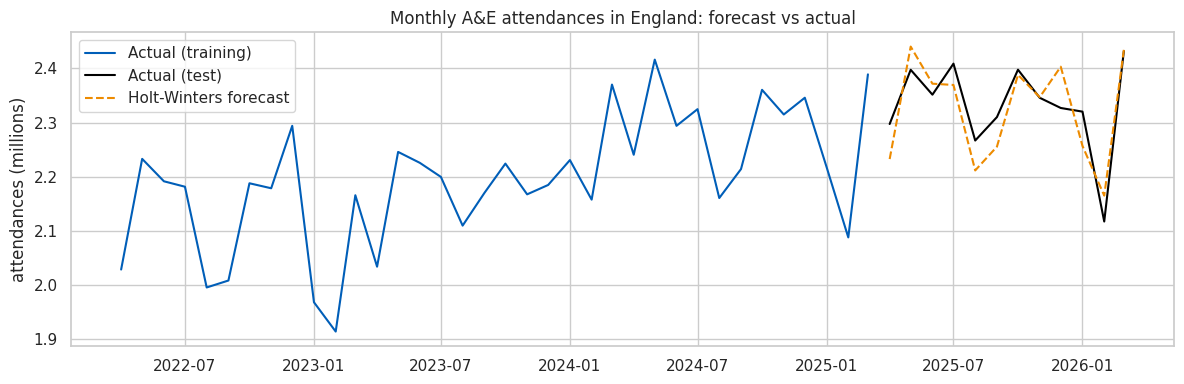

In [7]:
s = nat.set_index("month")["attendances"].asfreq("MS")
train, test = s[:"2025-03-01"], s["2025-04-01":]
hw = ExponentialSmoothing(train, trend="add", seasonal="mul", seasonal_periods=12).fit()
fc = hw.forecast(len(test))
naive = train[-12:].values
mape = lambda a,f: np.mean(np.abs((a-f)/a))*100
res_fc = pd.DataFrame({"model":["Holt-Winters","Seasonal naive (last year)"],
                       "MAPE %":[round(mape(test.values,fc.values),2), round(mape(test.values,naive),2)]})
print(res_fc.to_string(index=False))
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train/1e6, label="Actual (training)", color="#005EB8"); ax.plot(test/1e6, label="Actual (test)", color="black")
ax.plot(fc/1e6, "--", label="Holt-Winters forecast", color="#ED8B00")
ax.set(title="Monthly A&E attendances in England: forecast vs actual", ylabel="attendances (millions)"); ax.legend()
plt.tight_layout(); plt.savefig("charts/attendance_forecast.png", dpi=150); plt.show()

## 5. Findings
See README for the written summary.